In [1]:
from google.colab import drive

In [2]:
!pip -q install sentence-transformers fairlearn scikit-learn seaborn joblib

In [3]:
import os
import re
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

from fairlearn.metrics import MetricFrame, demographic_parity_difference, selection_rate

warnings.filterwarnings("ignore")

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [5]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
BASE_DIR = "/content/drive/MyDrive/MSc IT/3rd sem/model"
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

for folder in [BASE_DIR, DATA_DIR, MODEL_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [7]:
DATA_PATH = os.path.join(DATA_DIR, "resume_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1730, 11)


,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant
0,JOB004,R0001,Job Title: DevOps Engineer Company: CloudBase ...,Barbara Garcia Email: r0001@email.com SKILLS S...,"SQL, Jenkins, Ansible, Docker","BSc Statistics, University of Leeds (2017)",Machine Learning Engineer at CloudBase Ltd (20...,Google Professional Data Engineer,Female,White,0
1,JOB004,R0002,Job Title: DevOps Engineer Company: CloudBase ...,James Rodriguez Email: r0002@email.com SKILLS ...,"CI/CD, Kubernetes, Jenkins, Docker, Big Data, ...","MSc Computer Science, London Metropolitan Univ...",Backend Developer at TechCorp Ltd (2021-2022):...,"Tableau Desktop Specialist, Databricks Certifi...",Male,White,1
2,JOB004,R0003,Job Title: DevOps Engineer Company: CloudBase ...,Kwame Traoré Email: r0003@email.com SKILLS PyT...,"PyTorch, Deep Learning, Bash, R, AWS, NLP, Fas...","MSc Computer Science, University of Manchester...",Backend Developer at CloudBase Ltd (2018-2021)...,Microsoft Azure Fundamentals,Male,Black,0
3,JOB005,R0004,Job Title: Data Engineer Company: PrismData Lt...,Liam Martinez Email: r0004@email.com SKILLS SQ...,"SQL, Kubernetes, PostgreSQL, Jenkins, Redis, N...","BA Business Information Systems, City Universi...",Data Analyst at BetaWorks (2019-2022): Applied...,"Certified Ethical Hacker, AWS Machine Learning...",Male,White,1
4,JOB001,R0005,Job Title: Data Scientist Company: TechCorp Lt...,Fatima Taylor Email: r0005@email.com SKILLS Da...,"Data Visualisation, CI/CD, Computer Vision, Sc...","MSc Computer Science, University of Hertfordsh...",Backend Developer at Acme Digital (2022-2025):...,"Agile Scrum Master, Certified Ethical Hacker",Female,White,0


In [8]:
print(df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())

['job_id', 'resume_id', 'job_text', 'resume_text', 'skills_text', 'education_text', 'experience_text', 'certifications_text', 'gender', 'race', 'label_relevant']

Missing values:

job_id                   0
resume_id                0
job_text                 0
resume_text              0
skills_text              0
education_text           0
experience_text          0
certifications_text    402
gender                   0
race                     0
label_relevant           0
dtype: int64


In [9]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [10]:
text_columns = [
    "job_text",
    "resume_text",
    "skills_text",
    "education_text",
    "experience_text",
    "certifications_text"
]

for col in text_columns:
    df[col] = df[col].apply(clean_text)

df.head()

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant
0,JOB004,R0001,job title: devops engineer company: cloudbase ...,barbara garcia email: r0001@email.com skills s...,"sql, jenkins, ansible, docker","bsc statistics, university of leeds (2017)",machine learning engineer at cloudbase ltd (20...,google professional data engineer,Female,White,0
1,JOB004,R0002,job title: devops engineer company: cloudbase ...,james rodriguez email: r0002@email.com skills ...,"ci/cd, kubernetes, jenkins, docker, big data, ...","msc computer science, london metropolitan univ...",backend developer at techcorp ltd (2021-2022):...,"tableau desktop specialist, databricks certifi...",Male,White,1
2,JOB004,R0003,job title: devops engineer company: cloudbase ...,kwame traoré email: r0003@email.com skills pyt...,"pytorch, deep learning, bash, r, aws, nlp, fas...","msc computer science, university of manchester...",backend developer at cloudbase ltd (2018-2021)...,microsoft azure fundamentals,Male,Black,0
3,JOB005,R0004,job title: data engineer company: prismdata lt...,liam martinez email: r0004@email.com skills sq...,"sql, kubernetes, postgresql, jenkins, redis, n...","ba business information systems, city universi...",data analyst at betaworks (2019-2022): applied...,"certified ethical hacker, aws machine learning...",Male,White,1
4,JOB001,R0005,job title: data scientist company: techcorp lt...,fatima taylor email: r0005@email.com skills da...,"data visualisation, ci/cd, computer vision, sc...","msc computer science, university of hertfordsh...",backend developer at acme digital (2022-2025):...,"agile scrum master, certified ethical hacker",Female,White,0


In [11]:
print("Number of unique jobs:", df["job_id"].nunique())
print("Number of unique resumes:", df["resume_id"].nunique())

print("\nGender distribution:")
print(df["gender"].value_counts(dropna=False))

print("\nRace distribution:")
print(df["race"].value_counts(dropna=False))

print("\nLabel distribution:")
print(df["label_relevant"].value_counts(dropna=False))

Number of unique jobs: 5
Number of unique resumes: 1730

Gender distribution:
gender
Female        849
Male          805
Non-binary     76
Name: count, dtype: int64

Race distribution:
race
White       1397
Asian        127
Black         77
Hispanic      74
Other         55
Name: count, dtype: int64

Label distribution:
label_relevant
1    1050
0     680
Name: count, dtype: int64


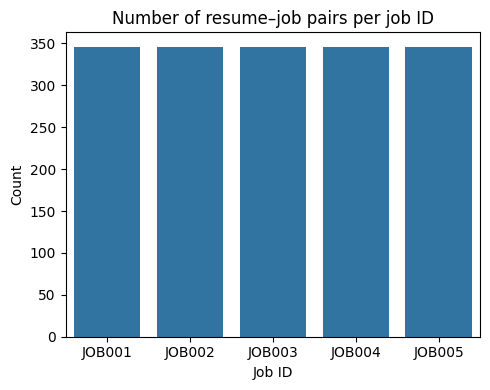

In [12]:
plt.figure(figsize=(5, 4))
job_counts = df["job_id"].value_counts().sort_index()
sns.barplot(x=job_counts.index, y=job_counts.values, color="#1f77b4")
plt.title("Number of resume–job pairs per job ID")
plt.xlabel("Job ID")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "jobid_counts.png"))
plt.show()

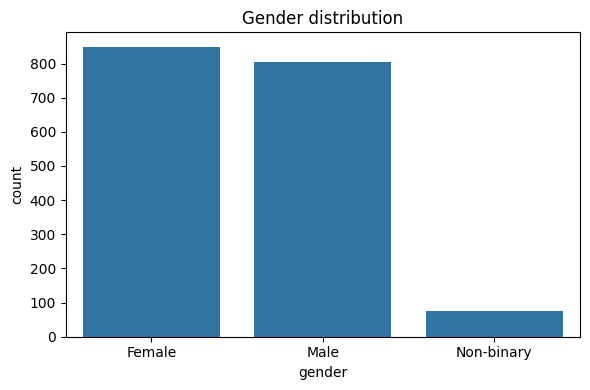

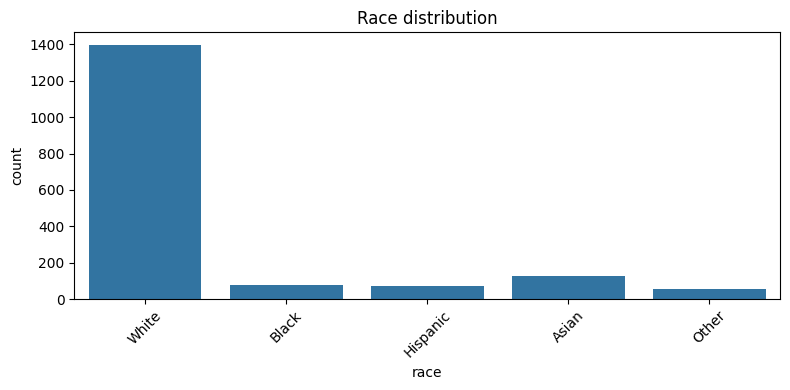

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="gender")
plt.title("Gender distribution")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "gender_distribution.png"))
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="race")
plt.title("Race distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "race_distribution.png"))
plt.show()

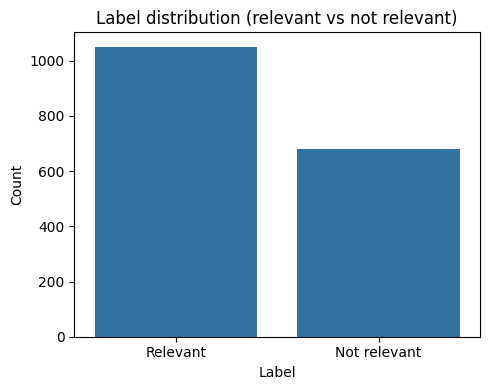

In [14]:
plt.figure(figsize=(5, 4))
label_names = {0: "Not relevant", 1: "Relevant"}
sns.countplot(
    data=df,
    x="label_relevant",
    order=[1, 0]
)
plt.title("Label distribution (relevant vs not relevant)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], [label_names[1], label_names[0]])
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "label_distribution.png"))
plt.show()

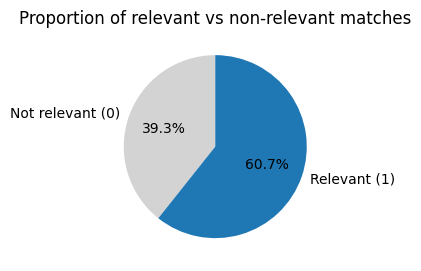

In [15]:
plt.figure(figsize=(4, 4))
label_counts = df["label_relevant"].value_counts().sort_index()
labels = ["Not relevant (0)", "Relevant (1)"]
plt.pie(
    label_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#d3d3d3", "#1f77b4"]
)
plt.title("Proportion of relevant vs non‑relevant matches")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "label_proportion_pie.png"))
plt.show()

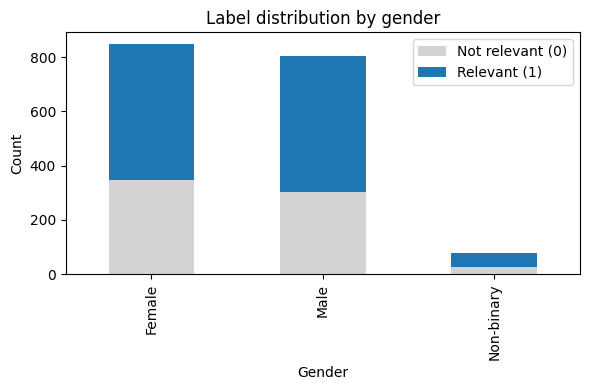

In [16]:
ct_gender = pd.crosstab(df["gender"], df["label_relevant"])

ct_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 4),
    color=["#d3d3d3", "#1f77b4"]
)
plt.title("Label distribution by gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(["Not relevant (0)", "Relevant (1)"])
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "label_by_gender_stacked.png"))
plt.show()

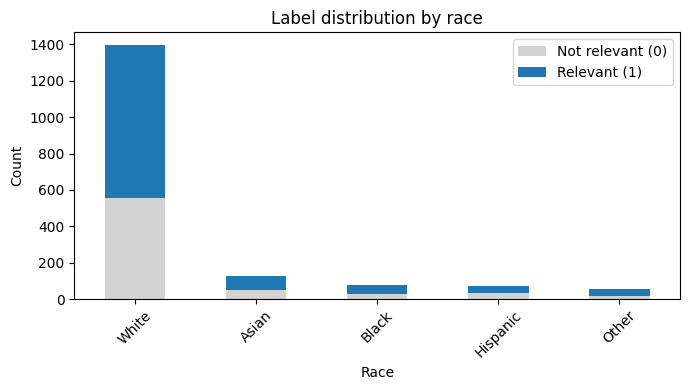

In [17]:
ct_race = pd.crosstab(df["race"], df["label_relevant"])
race_order = ["White", "Asian", "Black", "Hispanic", "Other"]
ct_race = ct_race.loc[race_order]

ct_race.plot(
    kind="bar",
    stacked=True,          # switch to False for grouped bars
    figsize=(7, 4),
    color=["#d3d3d3", "#1f77b4"]
)
plt.title("Label distribution by race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.legend(["Not relevant (0)", "Relevant (1)"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "label_by_race_stacked.png"))
plt.show()

In [18]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=SEED,
    stratify=df["label_relevant"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df["label_relevant"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1211, 11)
Validation shape: (259, 11)
Test shape: (260, 11)


In [19]:
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(embedding_model_name)

print("Loaded model:", embedding_model_name)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: sentence-transformers/all-MiniLM-L6-v2


In [20]:
def encode_texts(texts, model, batch_size=32):
    return model.encode(
        texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True
    )

In [21]:
train_job_emb = encode_texts(train_df["job_text"], embedder)
train_resume_emb = encode_texts(train_df["resume_text"], embedder)
train_skills_emb = encode_texts(train_df["skills_text"], embedder)
train_edu_emb = encode_texts(train_df["education_text"], embedder)
train_exp_emb = encode_texts(train_df["experience_text"], embedder)
train_cert_emb = encode_texts(train_df["certifications_text"], embedder)

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

In [22]:
val_job_emb = encode_texts(val_df["job_text"], embedder)
val_resume_emb = encode_texts(val_df["resume_text"], embedder)
val_skills_emb = encode_texts(val_df["skills_text"], embedder)
val_edu_emb = encode_texts(val_df["education_text"], embedder)
val_exp_emb = encode_texts(val_df["experience_text"], embedder)
val_cert_emb = encode_texts(val_df["certifications_text"], embedder)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

In [23]:
test_job_emb = encode_texts(test_df["job_text"], embedder)
test_resume_emb = encode_texts(test_df["resume_text"], embedder)
test_skills_emb = encode_texts(test_df["skills_text"], embedder)
test_edu_emb = encode_texts(test_df["education_text"], embedder)
test_exp_emb = encode_texts(test_df["experience_text"], embedder)
test_cert_emb = encode_texts(test_df["certifications_text"], embedder)

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

In [24]:
def rowwise_cosine(a, b):
    sims = []
    for i in range(len(a)):
        sim = cosine_similarity(a[i].reshape(1, -1), b[i].reshape(1, -1))[0][0]
        sims.append(sim)
    return np.array(sims)

In [25]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

for split_df, job_emb, resume_emb, skills_emb, edu_emb, exp_emb, cert_emb in [
    (train_df, train_job_emb, train_resume_emb, train_skills_emb, train_edu_emb, train_exp_emb, train_cert_emb),
    (val_df, val_job_emb, val_resume_emb, val_skills_emb, val_edu_emb, val_exp_emb, val_cert_emb),
    (test_df, test_job_emb, test_resume_emb, test_skills_emb, test_edu_emb, test_exp_emb, test_cert_emb),
]:
    split_df["full_similarity"] = rowwise_cosine(job_emb, resume_emb)
    split_df["skills_similarity"] = rowwise_cosine(job_emb, skills_emb)
    split_df["education_similarity"] = rowwise_cosine(job_emb, edu_emb)
    split_df["experience_similarity"] = rowwise_cosine(job_emb, exp_emb)
    split_df["certifications_similarity"] = rowwise_cosine(job_emb, cert_emb)

train_df.head()

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity
812,JOB002,R0813,job title: software engineer company: innovate...,raj moore email: r0813@email.com skills pandas...,"pandas, agile, rest apis, sql, aws, nlp, bash,...","msc artificial intelligence, university of she...",data analyst at innovatesoft (2015-2017): appl...,pmp project management,Male,White,1,0.585267,0.371033,0.172755,0.423030,0.159309
1637,JOB001,R1638,job title: data scientist company: techcorp lt...,jessica chen email: r1638@email.com skills red...,"redshift, spark, django, machine learning, air...","bsc computer science, university of sheffield ...",software engineer at starline systems (2019-20...,google cloud professional,Female,White,0,0.668563,0.436120,0.464719,0.605352,0.347251
1096,JOB004,R1097,job title: devops engineer company: cloudbase ...,maria nguyen email: r1097@email.com skills typ...,"typescript, azure, kubernetes, terraform, ci/cd","msc computer science, university of bristol (2...",machine learning engineer at byteforge (2022-2...,"tableau desktop specialist, certified kubernet...",Female,Black,0,0.664245,0.482480,0.185243,0.551203,0.526084
35,JOB004,R0036,job title: devops engineer company: cloudbase ...,barbara thompson email: r0036@email.com skills...,"statistics, kubernetes, terraform, bigquery, g...","bsc mathematics, university of sheffield (2010)",machine learning engineer at globaltech system...,"tableau desktop specialist, microsoft azure fu...",Female,White,1,0.673885,0.502344,0.090520,0.633546,0.397572
137,JOB001,R0138,job title: data scientist company: techcorp lt...,emma lopez email: r0138@email.com skills stati...,"statistics, python, data visualisation, sql, r...","msc artificial intelligence, coventry universi...",systems analyst at quantum analytics (2018-202...,certified kubernetes administrator,Female,White,1,0.686207,0.546726,0.335791,0.479008,0.303944


In [26]:
test_ranked = test_df.copy()
test_ranked["baseline_rank"] = test_ranked.groupby("job_id")["full_similarity"] \
    .rank(method="first", ascending=False)

test_ranked = test_ranked.sort_values(["job_id", "baseline_rank"])
test_ranked.head(20)

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity,baseline_rank
165,JOB001,R0166,job title: data scientist company: techcorp lt...,robert adeyemi email: r0166@email.com skills t...,"tensorflow, terraform, scikit-learn, statistic...","bsc software engineering, de montfort universi...",qa engineer at techcorp ltd (2015-2018): appli...,"tableau desktop specialist, certified kubernet...",Male,White,1,0.742984,0.577360,0.409890,0.633716,0.364784,1.0
1660,JOB001,R1661,job title: data scientist company: techcorp lt...,jordan kim email: r1661@email.com skills tenso...,"tensorflow, java, computer vision, a/b testing...","bsc cybersecurity, university of leeds (2012)",data analyst at cloudbase ltd (2021-2023): app...,"aws machine learning specialty, google cloud p...",Non-binary,White,1,0.738292,0.580433,0.375701,0.550816,0.612756,2.0
1495,JOB001,R1496,job title: data scientist company: techcorp lt...,lisa kim email: r1496@email.com skills machine...,"machine learning, docker, scikit-learn, java, ...","bsc cybersecurity, london metropolitan univers...",junior developer at datasolutions uk (2022-202...,"google professional data engineer, agile scrum...",Female,White,1,0.733346,0.503041,0.348067,0.605993,0.468799,3.0
127,JOB001,R0128,job title: data scientist company: techcorp lt...,jennifer perez email: r0128@email.com skills s...,"sql, statistics, data visualisation, tensorflo...","bsc software engineering, university of leeds ...",systems analyst at innovatesoft (2022-2025): a...,,Female,White,1,0.728833,0.603796,0.407414,0.630957,0.074907,4.0
858,JOB001,R0859,job title: data scientist company: techcorp lt...,elijah johnson email: r0859@email.com skills g...,"git, data visualisation, django, tensorflow, f...","beng information technology, coventry universi...",qa engineer at quantum analytics (2016-2017): ...,aws machine learning specialty,Male,White,1,0.704894,0.564563,0.269649,0.476671,0.558806,5.0
749,JOB001,R0750,job title: data scientist company: techcorp lt...,matthew nguyen email: r0750@email.com skills d...,"data visualisation, python, rest apis, sql, te...","beng information technology, university of bir...",junior developer at betaworks (2018-2021): app...,tableau desktop specialist,Male,White,1,0.703448,0.586154,0.337845,0.608004,0.327109,6.0
1434,JOB001,R1435,job title: data scientist company: techcorp lt...,jessica diallo email: r1435@email.com skills s...,"sql, statistics, scikit-learn, tensorflow, red...","beng information technology, university of bri...",data analyst at datasolutions uk (2022-2025): ...,,Female,White,1,0.703440,0.588194,0.344107,0.563549,0.074907,7.0
170,JOB001,R0171,job title: data scientist company: techcorp lt...,aisha rodriguez email: r0171@email.com skills ...,"ci/cd, data visualisation, ansible, machine le...","bsc statistics, london metropolitan university...",devops engineer at alphatech (2018-2019): appl...,,Female,White,0,0.702509,0.529867,0.292008,0.564827,0.074907,8.0
323,JOB001,R0324,job title: data scientist company: techcorp lt...,ava brown email: r0324@email.com skills python...,"python, feature engineering, machine learning,...","bsc software engineering, university of leeds ...",devops engineer at prismdata ltd (2016-2018): ...,"databricks certified associate, tensorflow dev...",Female,White,1,0.699950,0.612242,0.372743,0.501898,0.535936,9.0
654,JOB001,R0655,job title: data scientist company: techcorp lt...,lisa garcia email: r0655@email.com skills comp...,"computer vision, sql, python, node.js, system ...","bsc data science, university of birmingham (2023)",software engineer at alphatech (2018-2019): ap...,"aws certified developer, microsoft azure funda...",Female,White,1,0.699905,0.533613,0.538576,0.583365,0.401240,10.0


In [27]:
baseline_path = os.path.join(RESULTS_DIR, "baseline_rankings.csv")
test_ranked.to_csv(baseline_path, index=False)
print("Saved baseline rankings to:", baseline_path)

Saved baseline rankings to: /content/drive/MyDrive/MSc IT/3rd sem/model/results/baseline_rankings.csv


In [28]:
print("Mean full similarity by gender:")
print(test_ranked.groupby("gender")["full_similarity"].mean())

print("\nMean full similarity by race:")
print(test_ranked.groupby("race")["full_similarity"].mean())

Mean full similarity by gender:
gender
Female        0.636966
Male          0.630605
Non-binary    0.631847
Name: full_similarity, dtype: float32

Mean full similarity by race:
race
Asian       0.620730
Black       0.653573
Hispanic    0.643046
Other       0.634175
White       0.632562
Name: full_similarity, dtype: float32


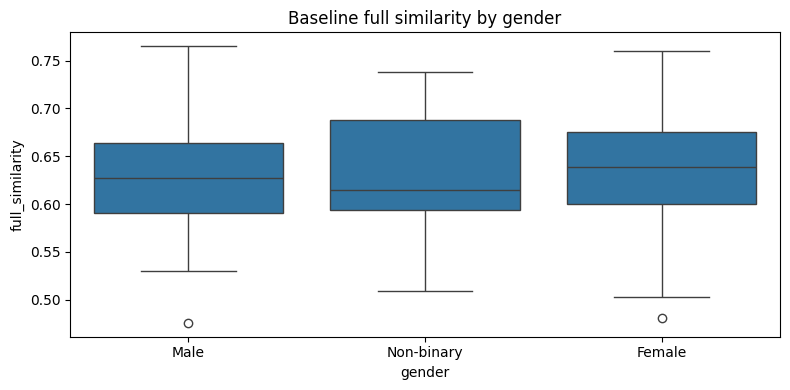

In [29]:
plt.figure(figsize=(8,4))
sns.boxplot(data=test_ranked, x="gender", y="full_similarity")
plt.title("Baseline full similarity by gender")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "baseline_similarity_by_gender.png"))
plt.show()

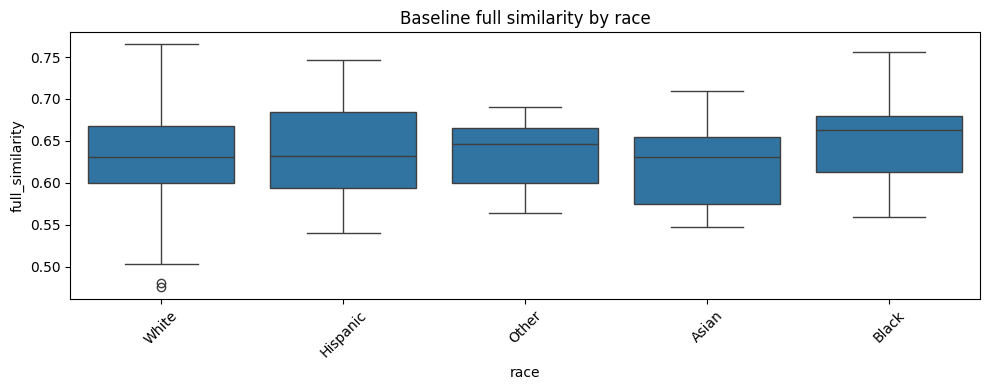

In [30]:
plt.figure(figsize=(10,4))
sns.boxplot(data=test_ranked, x="race", y="full_similarity")
plt.title("Baseline full similarity by race")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "baseline_similarity_by_race.png"))
plt.show()

In [31]:
TOP_K = 10

test_ranked["selected_top_k"] = (test_ranked["baseline_rank"] <= TOP_K).astype(int)
test_ranked[["job_id", "resume_id", "baseline_rank", "selected_top_k"]].head(20)

,job_id,resume_id,baseline_rank,selected_top_k
165,JOB001,R0166,1.0,1
1660,JOB001,R1661,2.0,1
1495,JOB001,R1496,3.0,1
127,JOB001,R0128,4.0,1
858,JOB001,R0859,5.0,1
749,JOB001,R0750,6.0,1
1434,JOB001,R1435,7.0,1
170,JOB001,R0171,8.0,1
323,JOB001,R0324,9.0,1
654,JOB001,R0655,10.0,1


In [32]:
print("Selection rate by gender:")
print(test_ranked.groupby("gender")["selected_top_k"].mean())

print("\nSelection rate by race:")
print(test_ranked.groupby("race")["selected_top_k"].mean())

Selection rate by gender:
gender
Female        0.224806
Male          0.147541
Non-binary    0.333333
Name: selected_top_k, dtype: float64

Selection rate by race:
race
Asian       0.071429
Black       0.312500
Hispanic    0.230769
Other       0.200000
White       0.188406
Name: selected_top_k, dtype: float64


In [33]:
dpd_gender = demographic_parity_difference(
    y_true=test_ranked["label_relevant"],
    y_pred=test_ranked["selected_top_k"],
    sensitive_features=test_ranked["gender"]
)

dpd_race = demographic_parity_difference(
    y_true=test_ranked["label_relevant"],
    y_pred=test_ranked["selected_top_k"],
    sensitive_features=test_ranked["race"]
)

print("Demographic parity difference (gender):", dpd_gender)
print("Demographic parity difference (race):", dpd_race)

Demographic parity difference (gender): 0.18579234972677594
Demographic parity difference (race): 0.24107142857142858


In [34]:
mf_gender = MetricFrame(
    metrics={"selection_rate": selection_rate},
    y_true=test_ranked["label_relevant"],
    y_pred=test_ranked["selected_top_k"],
    sensitive_features=test_ranked["gender"]
)

mf_race = MetricFrame(
    metrics={"selection_rate": selection_rate},
    y_true=test_ranked["label_relevant"],
    y_pred=test_ranked["selected_top_k"],
    sensitive_features=test_ranked["race"]
)

print("By gender:\n", mf_gender.by_group)
print("\nBy race:\n", mf_race.by_group)

By gender:
             selection_rate
gender                    
Female            0.224806
Male              0.147541
Non-binary        0.333333

By race:
           selection_rate
race                    
Asian           0.071429
Black           0.312500
Hispanic        0.230769
Other           0.200000
White           0.188406


In [35]:
section_cols = [
    "skills_similarity",
    "education_similarity",
    "experience_similarity",
    "certifications_similarity"
]

for col in section_cols:
    print(f"\nMean {col} by gender")
    print(test_ranked.groupby("gender")[col].mean())

for col in section_cols:
    print(f"\nMean {col} by race")
    print(test_ranked.groupby("race")[col].mean())


Mean skills_similarity by gender
gender
Female        0.444574
Male          0.437422
Non-binary    0.447198
Name: skills_similarity, dtype: float32

Mean education_similarity by gender
gender
Female        0.284699
Male          0.281391
Non-binary    0.275798
Name: education_similarity, dtype: float32

Mean experience_similarity by gender
gender
Female        0.483340
Male          0.492693
Non-binary    0.468581
Name: experience_similarity, dtype: float32

Mean certifications_similarity by gender
gender
Female        0.336808
Male          0.330649
Non-binary    0.395466
Name: certifications_similarity, dtype: float32

Mean skills_similarity by race
race
Asian       0.428514
Black       0.450723
Hispanic    0.454015
Other       0.432634
White       0.441068
Name: skills_similarity, dtype: float32

Mean education_similarity by race
race
Asian       0.289020
Black       0.239607
Hispanic    0.278018
Other       0.260637
White       0.287138
Name: education_similarity, dtype: float32


In [36]:
gender_encoder = LabelEncoder()

train_gender = gender_encoder.fit_transform(train_df["gender"])
test_gender = gender_encoder.transform(test_df["gender"])

gender_probe = LogisticRegression(max_iter=1000, random_state=SEED)
gender_probe.fit(train_resume_emb, train_gender)

gender_pred = gender_probe.predict(test_resume_emb)

print("Gender probe accuracy:", accuracy_score(test_gender, gender_pred))
print("Gender probe F1:", f1_score(test_gender, gender_pred, average="weighted"))
print("\nClassification report:\n")
print(classification_report(test_gender, gender_pred))

Gender probe accuracy: 0.9461538461538461
Gender probe F1: 0.929459685888586

Classification report:

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       129
           1       0.95      0.97      0.96       122
           2       0.00      0.00      0.00         9

    accuracy                           0.95       260
   macro avg       0.63      0.65      0.64       260
weighted avg       0.91      0.95      0.93       260



In [37]:
race_encoder = LabelEncoder()

train_race = race_encoder.fit_transform(train_df["race"])
test_race = race_encoder.transform(test_df["race"])

race_probe = LogisticRegression(max_iter=1000, random_state=SEED)
race_probe.fit(train_resume_emb, train_race)

race_pred = race_probe.predict(test_resume_emb)

print("Race probe accuracy:", accuracy_score(test_race, race_pred))
print("Race probe F1:", f1_score(test_race, race_pred, average="weighted"))
print("\nClassification report:\n")
print(classification_report(test_race, race_pred))

Race probe accuracy: 0.7961538461538461
Race probe F1: 0.7057980563333883

Classification report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.00      0.00      0.00        16
           2       0.00      0.00      0.00        13
           3       0.00      0.00      0.00        10
           4       0.80      1.00      0.89       207

    accuracy                           0.80       260
   macro avg       0.16      0.20      0.18       260
weighted avg       0.63      0.80      0.71       260



In [38]:
feature_cols = [
    "full_similarity",
    "skills_similarity",
    "education_similarity",
    "experience_similarity",
    "certifications_similarity"
]

X_train = train_df[feature_cols]
y_train = train_df["label_relevant"]

X_val = val_df[feature_cols]
y_val = val_df["label_relevant"]

X_test = test_df[feature_cols]
y_test = test_df["label_relevant"]

In [39]:
scorer_model = LogisticRegression(max_iter=1000, random_state=SEED)
scorer_model.fit(X_train, y_train)

val_pred = scorer_model.predict(X_val)
test_pred = scorer_model.predict(X_test)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation F1:", f1_score(y_val, val_pred))

print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test F1:", f1_score(y_test, test_pred))

Validation Accuracy: 0.7181467181467182
Validation F1: 0.7859237536656891
Test Accuracy: 0.7653846153846153
Test F1: 0.8231884057971014


In [40]:
weights = scorer_model.coef_[0]
intercept = scorer_model.intercept_[0]

weight_mapping = pd.DataFrame({
    'Feature': feature_cols,
    'Learned_Weight': weights
}).sort_values(by='Learned_Weight', ascending=False)

print("Model Intercept:", intercept)
display(weight_mapping)

Model Intercept: -6.0018765293942105


,Feature,Learned_Weight
1,skills_similarity,9.047881
0,full_similarity,4.944930
4,certifications_similarity,-0.191051
3,experience_similarity,-0.562963
2,education_similarity,-1.052003


In [41]:
test_df["fair_score_raw"] = scorer_model.predict_proba(X_test)[:, 1]
test_df.head()

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity,fair_score_raw
815,JOB002,R0816,job title: software engineer company: innovate...,elijah martinez email: r0816@email.com skills ...,"docker, agile, aws, fastapi, pytorch, ci/cd, r...","msc artificial intelligence, de montfort unive...",junior developer at acme digital (2021-2023): ...,,Male,White,0,0.544791,0.415674,0.175393,0.282287,0.098499,0.522683
1259,JOB003,R1260,job title: machine learning engineer company: ...,kevin gonzalez email: r1260@email.com skills e...,"etl, big data, django, nlp, rest apis, mongodb...","bsc cybersecurity, northumbria university (2018)",data analyst at datasolutions uk (2017-2020): ...,,Male,White,1,0.619841,0.487151,0.336544,0.484751,0.106923,0.694981
1598,JOB002,R1599,job title: software engineer company: innovate...,olivia moore email: r1599@email.com skills azu...,"azure, docker, hadoop, git, kafka","msc artificial intelligence, university of bir...",backend developer at nexgen analytics (2022-20...,"tableau desktop specialist, tensorflow develop...",Female,White,0,0.639757,0.423695,0.224381,0.389064,0.310771,0.617929
409,JOB004,R0410,job title: devops engineer company: cloudbase ...,liam anderson email: r0410@email.com skills gi...,"git, docker, system design, aws, tableau, c++,...","beng information technology, coventry universi...",software engineer at nexgen analytics (2021-20...,,Male,White,1,0.650654,0.546770,0.234173,0.544926,0.072838,0.831407
1397,JOB002,R1398,job title: software engineer company: innovate...,olivia thomas email: r1398@email.com skills ag...,"agile, javascript, r, sql","bsc data science, university of greenwich (2024)",qa engineer at quantum analytics (2015-2017): ...,"google cloud professional, aws solutions archi...",Female,White,0,0.629356,0.324968,0.255451,0.452887,0.499700,0.361550


In [42]:
test_df["fair_score_adjusted"] = test_df["fair_score_raw"].copy()

# 1. Gender Adjustment
gender_means = test_df.groupby("gender")["fair_score_raw"].mean().to_dict()
overall_mean = test_df["fair_score_raw"].mean()

for g in gender_means:
    adjustment = overall_mean - gender_means[g]
    test_df.loc[test_df["gender"] == g, "fair_score_adjusted"] += 0.1 * adjustment

# 2. Race Adjustment
race_means = test_df.groupby("race")["fair_score_raw"].mean().to_dict()

for r in race_means:
    adjustment = overall_mean - race_means[r]
    # Using a 0.15 weight for race as it often requires a stronger nudge in smaller samples
    test_df.loc[test_df["race"] == r, "fair_score_adjusted"] += 0.05 * adjustment

test_df["fair_score_adjusted"] = test_df["fair_score_adjusted"].clip(0, 1)
display(test_df.head())

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity,fair_score_raw,fair_score_adjusted
815,JOB002,R0816,job title: software engineer company: innovate...,elijah martinez email: r0816@email.com skills ...,"docker, agile, aws, fastapi, pytorch, ci/cd, r...","msc artificial intelligence, de montfort unive...",junior developer at acme digital (2021-2023): ...,,Male,White,0,0.544791,0.415674,0.175393,0.282287,0.098499,0.522683,0.523898
1259,JOB003,R1260,job title: machine learning engineer company: ...,kevin gonzalez email: r1260@email.com skills e...,"etl, big data, django, nlp, rest apis, mongodb...","bsc cybersecurity, northumbria university (2018)",data analyst at datasolutions uk (2017-2020): ...,,Male,White,1,0.619841,0.487151,0.336544,0.484751,0.106923,0.694981,0.696196
1598,JOB002,R1599,job title: software engineer company: innovate...,olivia moore email: r1599@email.com skills azu...,"azure, docker, hadoop, git, kafka","msc artificial intelligence, university of bir...",backend developer at nexgen analytics (2022-20...,"tableau desktop specialist, tensorflow develop...",Female,White,0,0.639757,0.423695,0.224381,0.389064,0.310771,0.617929,0.617035
409,JOB004,R0410,job title: devops engineer company: cloudbase ...,liam anderson email: r0410@email.com skills gi...,"git, docker, system design, aws, tableau, c++,...","beng information technology, coventry universi...",software engineer at nexgen analytics (2021-20...,,Male,White,1,0.650654,0.546770,0.234173,0.544926,0.072838,0.831407,0.832622
1397,JOB002,R1398,job title: software engineer company: innovate...,olivia thomas email: r1398@email.com skills ag...,"agile, javascript, r, sql","bsc data science, university of greenwich (2024)",qa engineer at quantum analytics (2015-2017): ...,"google cloud professional, aws solutions archi...",Female,White,0,0.629356,0.324968,0.255451,0.452887,0.499700,0.361550,0.360656


In [43]:
test_df["fair_rank"] = test_df.groupby("job_id")["fair_score_adjusted"] \
    .rank(method="first", ascending=False)

test_df = test_df.sort_values(["job_id", "fair_rank"])
test_df.head(20)

,job_id,resume_id,job_text,resume_text,skills_text,education_text,experience_text,certifications_text,gender,race,label_relevant,full_similarity,skills_similarity,education_similarity,experience_similarity,certifications_similarity,fair_score_raw,fair_score_adjusted,fair_rank
127,JOB001,R0128,job title: data scientist company: techcorp lt...,jennifer perez email: r0128@email.com skills s...,"sql, statistics, data visualisation, tensorflo...","bsc software engineering, university of leeds ...",systems analyst at innovatesoft (2022-2025): a...,,Female,White,1,0.728833,0.603796,0.407414,0.630957,0.074907,0.906116,0.905222,1.0
323,JOB001,R0324,job title: data scientist company: techcorp lt...,ava brown email: r0324@email.com skills python...,"python, feature engineering, machine learning,...","bsc software engineering, university of leeds ...",devops engineer at prismdata ltd (2016-2018): ...,"databricks certified associate, tensorflow dev...",Female,White,1,0.699950,0.612242,0.372743,0.501898,0.535936,0.902186,0.901292,2.0
1434,JOB001,R1435,job title: data scientist company: techcorp lt...,jessica diallo email: r1435@email.com skills s...,"sql, statistics, scikit-learn, tensorflow, red...","beng information technology, university of bri...",data analyst at datasolutions uk (2022-2025): ...,,Female,White,1,0.703440,0.588194,0.344107,0.563549,0.074907,0.891381,0.890487,3.0
1660,JOB001,R1661,job title: data scientist company: techcorp lt...,jordan kim email: r1661@email.com skills tenso...,"tensorflow, java, computer vision, a/b testing...","bsc cybersecurity, university of leeds (2012)",data analyst at cloudbase ltd (2021-2023): app...,"aws machine learning specialty, google cloud p...",Non-binary,White,1,0.738292,0.580433,0.375701,0.550816,0.612756,0.888768,0.887898,4.0
165,JOB001,R0166,job title: data scientist company: techcorp lt...,robert adeyemi email: r0166@email.com skills t...,"tensorflow, terraform, scikit-learn, statistic...","bsc software engineering, de montfort universi...",qa engineer at techcorp ltd (2015-2018): appli...,"tableau desktop specialist, certified kubernet...",Male,White,1,0.742984,0.577360,0.409890,0.633716,0.364784,0.884766,0.885981,5.0
749,JOB001,R0750,job title: data scientist company: techcorp lt...,matthew nguyen email: r0750@email.com skills d...,"data visualisation, python, rest apis, sql, te...","beng information technology, university of bir...",junior developer at betaworks (2018-2021): app...,tableau desktop specialist,Male,White,1,0.703448,0.586154,0.337845,0.608004,0.327109,0.882870,0.884085,6.0
858,JOB001,R0859,job title: data scientist company: techcorp lt...,elijah johnson email: r0859@email.com skills g...,"git, data visualisation, django, tensorflow, f...","beng information technology, coventry universi...",qa engineer at quantum analytics (2016-2017): ...,aws machine learning specialty,Male,White,1,0.704894,0.564563,0.269649,0.476671,0.558806,0.873592,0.874807,7.0
170,JOB001,R0171,job title: data scientist company: techcorp lt...,aisha rodriguez email: r0171@email.com skills ...,"ci/cd, data visualisation, ansible, machine le...","bsc statistics, london metropolitan university...",devops engineer at alphatech (2018-2019): appl...,,Female,White,0,0.702509,0.529867,0.292008,0.564827,0.074907,0.835713,0.834819,8.0
1159,JOB001,R1160,job title: data scientist company: techcorp lt...,kevin williams email: r1160@email.com skills s...,"statistics, elasticsearch, tableau, agile, nod...","bsc mathematics, king's college london (2022)",software engineer at byteforge (2017-2020): ap...,"pmp project management, databricks certified a...",Male,Other,1,0.651302,0.530361,0.309837,0.376696,0.450760,0.801115,0.802831,9.0
1588,JOB001,R1589,job title: data scientist company: techcorp lt...,noah johnson email: r1589@email.com skills kub...,"kubernetes, tensorflow, dbt, data visualisatio...","bsc cybersecurity, king's college london (2019)",devops engineer at betaworks (2020-2021): appl...,"aws certified d

In [44]:
TOP_K = 10
test_df["selected_top_k_fair"] = (test_df["fair_rank"] <= TOP_K).astype(int)

dpd_gender_fair = demographic_parity_difference(
    y_true=test_df["label_relevant"],
    y_pred=test_df["selected_top_k_fair"],
    sensitive_features=test_df["gender"]
)

dpd_race_fair = demographic_parity_difference(
    y_true=test_df["label_relevant"],
    y_pred=test_df["selected_top_k_fair"],
    sensitive_features=test_df["race"]
)

print("Fair scorer DPD (gender):", dpd_gender_fair)
print("Fair scorer DPD (race):", dpd_race_fair)

Fair scorer DPD (gender): 0.033697632058287796
Fair scorer DPD (race): 0.275


New changes

In [45]:
def soft_fair_rerank_intersection(group_df, score_col="fair_score_adjusted",
                                  gender_col="gender", race_col="race",
                                  top_k=10, alpha_gender=0.05, alpha_race=0.05):
    df = group_df.sort_values(score_col, ascending=False).copy()

    gender_targets = df[gender_col].value_counts(normalize=True).to_dict()
    race_targets = df[race_col].value_counts(normalize=True).to_dict()

    gender_counts = {g: 0 for g in df[gender_col].unique()}
    race_counts = {r: 0 for r in df[race_col].unique()}

    selected = []
    remaining = df.copy()

    for step in range(top_k):
        if len(remaining) == 0:
            break

        best_idx = None
        best_score = -np.inf

        for idx, row in remaining.iterrows():
            g = row[gender_col]
            r = row[race_col]

            if step == 0:
                current_gender_prop = 0.0
                current_race_prop = 0.0
            else:
                current_gender_prop = gender_counts[g] / step
                current_race_prop = race_counts[r] / step

            gender_penalty = max(0.0, current_gender_prop - gender_targets.get(g, 0.0))
            race_penalty = max(0.0, current_race_prop - race_targets.get(r, 0.0))

            penalized_score = (
                row[score_col]
                - alpha_gender * gender_penalty
                - alpha_race * race_penalty
            )

            if penalized_score > best_score:
                best_score = penalized_score
                best_idx = idx

        chosen = remaining.loc[[best_idx]]
        selected.append(chosen)

        gender_counts[chosen.iloc[0][gender_col]] += 1
        race_counts[chosen.iloc[0][race_col]] += 1
        remaining = remaining.drop(best_idx)

    selected_df = pd.concat(selected)
    leftover_df = remaining.sort_values(score_col, ascending=False)
    final_df = pd.concat([selected_df, leftover_df], axis=0).reset_index(drop=True)
    final_df["reranked_position"] = np.arange(1, len(final_df) + 1)
    return final_df

In [46]:
TOPK = 10
ALPHA_GENDER = 0.05
ALPHA_RACE = 0.1

reranked_list = []

for job_id, group in test_df.groupby("job_id"):
    reranked_group = soft_fair_rerank_intersection(
        group_df=group,
        score_col="fair_score_adjusted",
        gender_col="gender",
        race_col="race",
        top_k=TOPK,
        alpha_gender=ALPHA_GENDER,
        alpha_race=ALPHA_RACE
    )
    reranked_group["job_id"] = job_id
    reranked_list.append(reranked_group)

reranked_df = pd.concat(reranked_list, ignore_index=True)
reranked_df["selected_top_k_reranked"] = (reranked_df["reranked_position"] <= TOPK).astype(int)

In [47]:
reranked_gender_dpd = demographic_parity_difference(
    y_true=reranked_df["label_relevant"],
    y_pred=reranked_df["selected_top_k_reranked"],
    sensitive_features=reranked_df["gender"]
)

reranked_race_dpd = demographic_parity_difference(
    y_true=reranked_df["label_relevant"],
    y_pred=reranked_df["selected_top_k_reranked"],
    sensitive_features=reranked_df["race"]
)

print("Reranked gender DPD:", reranked_gender_dpd)
print("Reranked race DPD:", reranked_race_dpd)

Reranked gender DPD: 0.033697632058287796
Reranked race DPD: 0.275


In [48]:
baseline_gender_dpd = dpd_gender
fair_gender_dpd = dpd_gender_fair
reranked_gender_dpd = demographic_parity_difference(
    y_true=reranked_df["label_relevant"],
    y_pred=reranked_df["selected_top_k_fair"],
    sensitive_features=reranked_df["gender"]
)

baseline_race_dpd = dpd_race
fair_race_dpd = dpd_race_fair
reranked_race_dpd = demographic_parity_difference(
    y_true=reranked_df["label_relevant"],
    y_pred=reranked_df["selected_top_k_fair"],
    sensitive_features=reranked_df["race"]
)

comparison_df = pd.DataFrame({
    "system": ["baseline", "fair_scorer", "fair_scorer_soft_reranking"],
    "gender_dpd": [baseline_gender_dpd, fair_gender_dpd, reranked_gender_dpd],
    "race_dpd": [baseline_race_dpd, fair_race_dpd, reranked_race_dpd]
})

comparison_df

,system,gender_dpd,race_dpd
0,baseline,0.185792,0.241071
1,fair_scorer,0.033698,0.275000
2,fair_scorer_soft_reranking,0.033698,0.275000


Resulting images

In [49]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

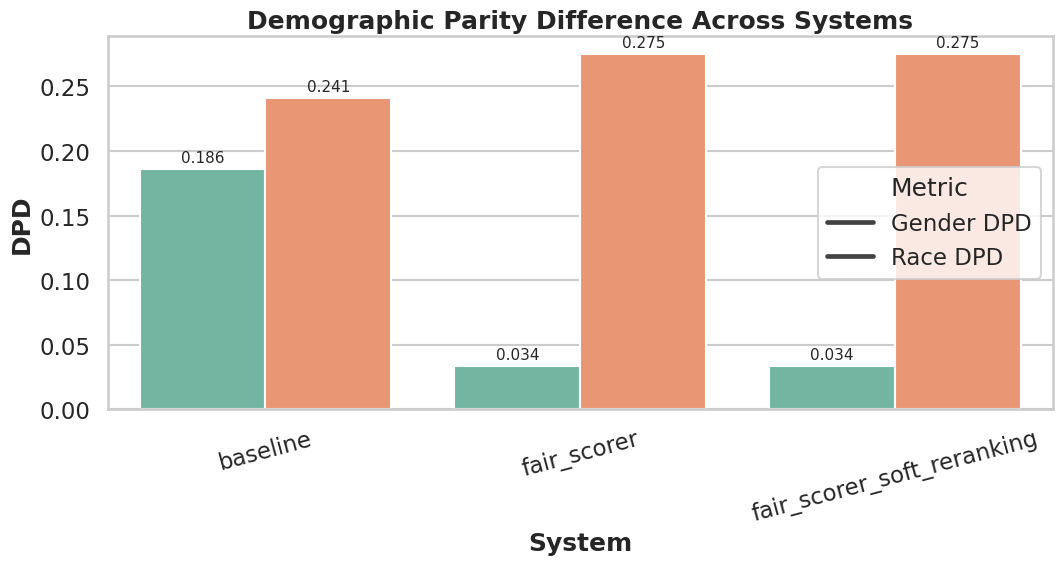

In [50]:
plot_df = comparison_df.melt(
    id_vars="system",
    value_vars=["gender_dpd", "race_dpd"],
    var_name="metric",
    value_name="dpd"
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_df, x="system", y="dpd", hue="metric", palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=11)

plt.title("Demographic Parity Difference Across Systems")
plt.xlabel("System")
plt.ylabel("DPD")
plt.xticks(rotation=15)
plt.legend(title="Metric", labels=["Gender DPD", "Race DPD"])
plt.tight_layout()
plt.show()

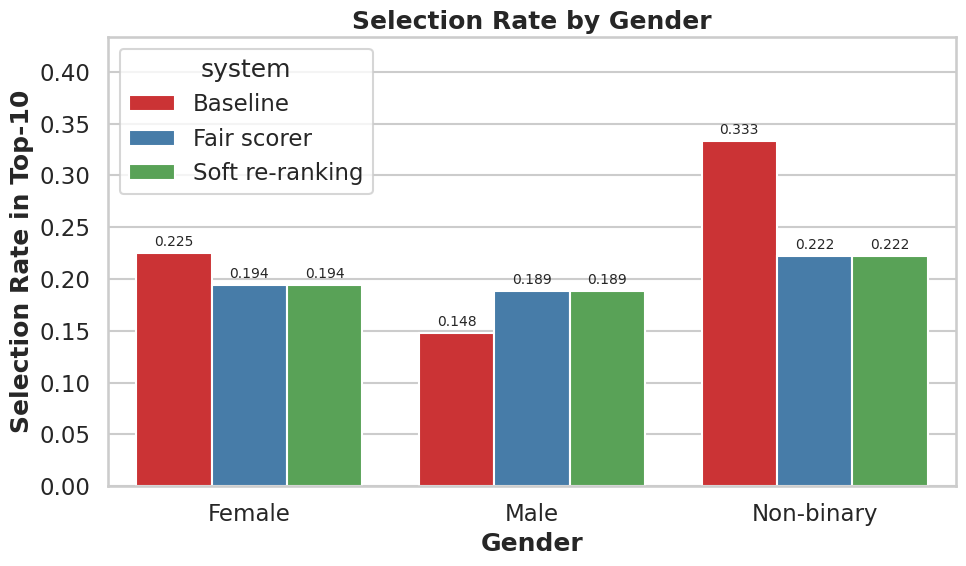

In [51]:
gender_baseline = (
    test_ranked.groupby("gender")["selected_top_k"]
    .mean()
    .reset_index(name="selection_rate")
)
gender_baseline["system"] = "Baseline"

gender_fair = (
    test_df.groupby("gender")["selected_top_k_fair"]
    .mean()
    .reset_index(name="selection_rate")
)
gender_fair["system"] = "Fair scorer"

gender_reranked = (
    reranked_df.groupby("gender")["selected_top_k_fair"]
    .mean()
    .reset_index(name="selection_rate")
)
gender_reranked["system"] = "Soft re-ranking"

gender_compare = pd.concat([gender_baseline, gender_fair, gender_reranked], ignore_index=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=gender_compare, x="gender", y="selection_rate", hue="system", palette="Set1")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.title("Selection Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Selection Rate in Top-10")
plt.ylim(0, max(gender_compare["selection_rate"]) + 0.1)
plt.tight_layout()
plt.show()

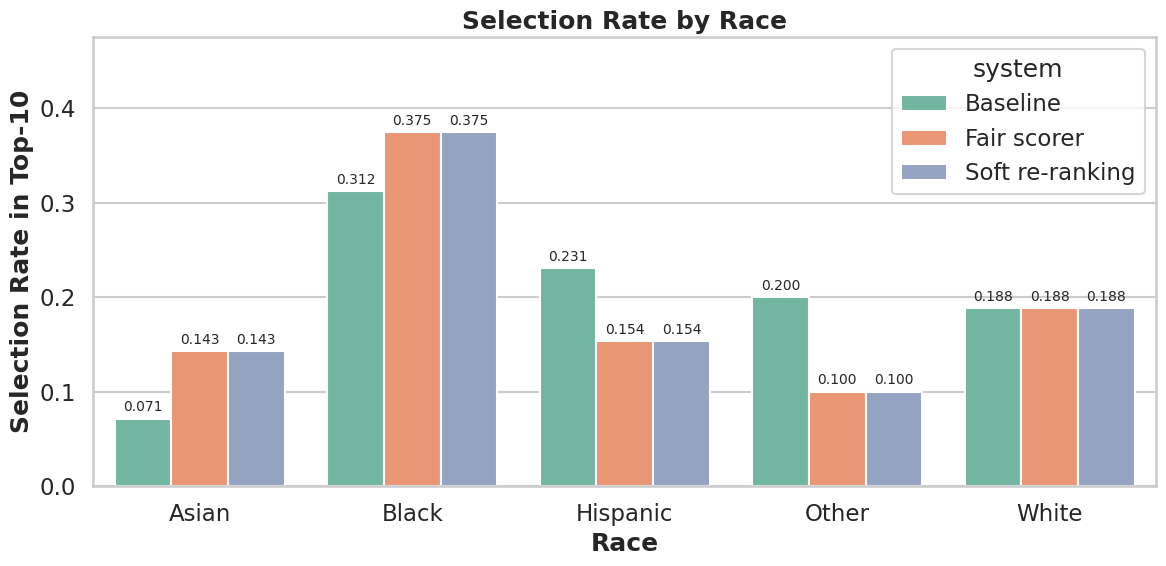

In [52]:
race_baseline = (
    test_ranked.groupby("race")["selected_top_k"]
    .mean()
    .reset_index(name="selection_rate")
)
race_baseline["system"] = "Baseline"

race_fair = (
    test_df.groupby("race")["selected_top_k_fair"]
    .mean()
    .reset_index(name="selection_rate")
)
race_fair["system"] = "Fair scorer"

race_reranked = (
    reranked_df.groupby("race")["selected_top_k_fair"]
    .mean()
    .reset_index(name="selection_rate")
)
race_reranked["system"] = "Soft re-ranking"

race_compare = pd.concat([race_baseline, race_fair, race_reranked], ignore_index=True)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=race_compare, x="race", y="selection_rate", hue="system", palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.title("Selection Rate by Race")
plt.xlabel("Race")
plt.ylabel("Selection Rate in Top-10")
plt.ylim(0, max(race_compare["selection_rate"]) + 0.1)
plt.tight_layout()
plt.show()

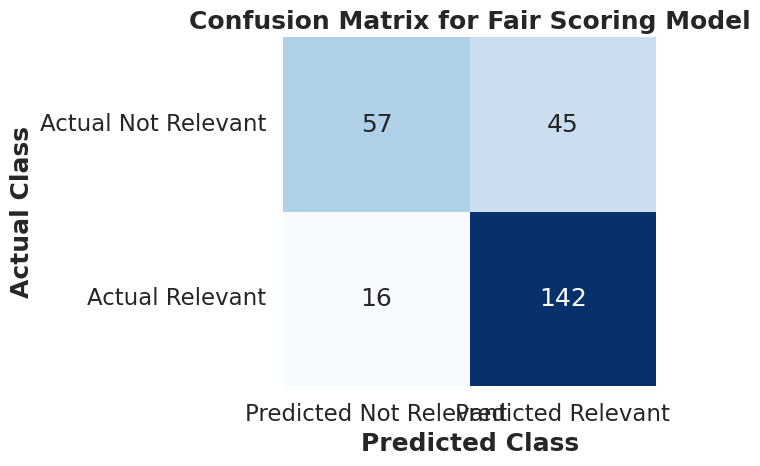

,Predicted Not Relevant,Predicted Relevant
Actual Not Relevant,57,45
Actual Relevant,16,142


In [53]:
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Relevant", "Actual Relevant"],
    columns=["Predicted Not Relevant", "Predicted Relevant"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Fair Scoring Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

display(cm_df)

Saving models

In [54]:
joblib.dump(scorer_model, os.path.join(MODEL_DIR, "fair_scorer_model.joblib"))
joblib.dump(gender_probe, os.path.join(MODEL_DIR, "gender_probe_model.joblib"))
joblib.dump(race_probe, os.path.join(MODEL_DIR, "race_probe_model.joblib"))

print("Models saved successfully.")

Models saved successfully.


In [55]:
test_ranked.to_csv(os.path.join(RESULTS_DIR, "baseline_rankings.csv"), index=False)
test_df.to_csv(os.path.join(RESULTS_DIR, "fair_scorer_results.csv"), index=False)
reranked_df.to_csv(os.path.join(RESULTS_DIR, "reranked_results.csv"), index=False)
comparison_df.to_csv(os.path.join(RESULTS_DIR, "fairness_comparison.csv"), index=False)

print("All results saved successfully.")

All results saved successfully.


In [56]:
utility_df = pd.DataFrame({
    "system": ["baseline_proxy", "fair_scorer"],
    "accuracy": [
        np.nan,
        accuracy_score(y_test, scorer_model.predict(X_test))
    ],
    "f1": [
        np.nan,
        f1_score(y_test, scorer_model.predict(X_test))
    ]
})

utility_df

,system,accuracy,f1
0,baseline_proxy,NaN,NaN
1,fair_scorer,0.765385,0.823188


In [57]:
print("Notebook completed successfully.")
print("Saved files in:")
print("Data:", DATA_DIR)
print("Models:", MODEL_DIR)
print("Results:", RESULTS_DIR)
print("Plots:", PLOTS_DIR)

Notebook completed successfully.
Saved files in:
Data: /content/drive/MyDrive/MSc IT/3rd sem/model/data
Models: /content/drive/MyDrive/MSc IT/3rd sem/model/models
Results: /content/drive/MyDrive/MSc IT/3rd sem/model/results
Plots: /content/drive/MyDrive/MSc IT/3rd sem/model/results/plots
